# Phase 1 SZZ Results Analysis
This notebook analyzes the results from Phase 1 of the SZZ pipeline execution across 21 projects and 6 SZZ variants, comparing them against the JIT-Defects4J ground truth dataset.

**Updates:** Includes Matthews Correlation Coefficient (MCC) and a Cohen's Kappa agreement heatmap.


In [1]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import precision_score, recall_score, f1_score, confusion_matrix, matthews_corrcoef, cohen_kappa_score

sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = (12, 8)


## 1. Load Ground Truth Data

In [2]:
ground_truth_path = '../data/raw/jit_ground_truth.csv'
gt_df = pd.read_csv(ground_truth_path)

gt_df = gt_df.drop_duplicates(subset=['project', 'commit_id'])
print(f"Loaded ground truth with {len(gt_df)} rows.")


Loaded ground truth with 27319 rows.


## 2. Load and Process Phase 1 Results

In [3]:
phase1_dir = '../results/phase1/'
files = [f for f in os.listdir(phase1_dir) if f.endswith('.csv')]

results_list = []

for file in files:
    parts = file.replace('_labels.csv', '').split('_')
    if len(parts) >= 2:
        variant = parts[0]
        project = "_".join(parts[1:])
        
        filepath = os.path.join(phase1_dir, file)
        df = pd.read_csv(filepath)
        
        label_col = f"label_{variant.upper()}"
        if label_col in df.columns:
            df['project'] = project
            df['variant'] = variant
            df = df.rename(columns={label_col: 'predicted_label'})
            results_list.append(df[['project', 'commit_id', 'variant', 'predicted_label']])

results_df = pd.concat(results_list, ignore_index=True)
print(f"Loaded {len(files)} result files. Total predictions: {len(results_df)}")


Loaded 126 result files. Total predictions: 493989


## 3. Merge Ground Truth with Predictions

In [4]:
merged_df = pd.merge(
    results_df, 
    gt_df, 
    on=['project', 'commit_id'], 
    how='inner'
)
print(f"Total evaluated commits after merging: {len(merged_df)}")


Total evaluated commits after merging: 157750


## 4. Calculate Evaluation Metrics (Including MCC)

In [5]:
def evaluate_performance(df):
    y_true = df['label_oracle']
    y_pred = df['predicted_label']
    
    cm = confusion_matrix(y_true, y_pred)
    tn, fp, fn, tp = cm.ravel() if len(cm.ravel()) == 4 else (0,0,0,0)
    
    precision = precision_score(y_true, y_pred, zero_division=0)
    recall = recall_score(y_true, y_pred, zero_division=0)
    f1 = f1_score(y_true, y_pred, zero_division=0)
    mcc = matthews_corrcoef(y_true, y_pred)
    
    return pd.Series({
        'TP': tp, 'FP': fp, 'TN': tn, 'FN': fn,
        'Precision': precision,
        'Recall': recall,
        'F1_Score': f1,
        'MCC': mcc
    })

# Aggregated metrics (All projects combined per variant)
aggregated_metrics = merged_df.groupby('variant').apply(evaluate_performance).reset_index()

# Project-level metrics
project_metrics = merged_df.groupby(['variant', 'project']).apply(evaluate_performance).reset_index()

display(aggregated_metrics.sort_values(by='MCC', ascending=False))


,variant,TP,FP,TN,FN,Precision,Recall,F1_Score,MCC
1,bszz,1410.0,5908.0,16256.0,739.0,0.192676,0.656119,0.297877,0.241080
0,agszz,961.0,3513.0,18651.0,1188.0,0.214797,0.447185,0.290201,0.211474
2,lszz,598.0,1532.0,23455.0,1696.0,0.280751,0.260680,0.270344,0.206225
3,maszz,1071.0,4323.0,20664.0,1223.0,0.198554,0.466870,0.278616,0.204760
4,raszz,882.0,3271.0,21716.0,1412.0,0.212377,0.384481,0.273616,0.195888
5,rszz,654.0,2045.0,22942.0,1640.0,0.242312,0.285092,0.261967,0.188917


## 5. Visualizations

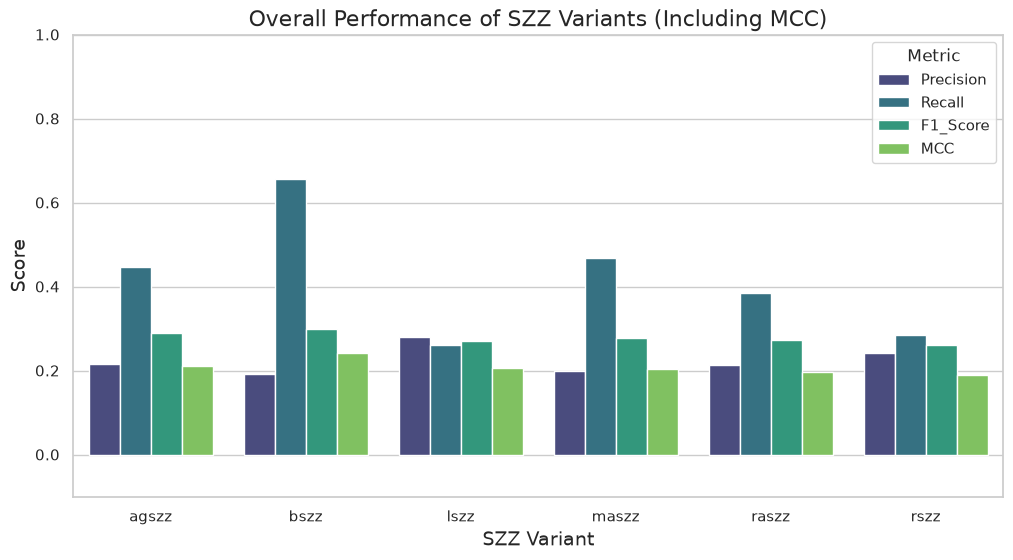

In [14]:
metrics_melted = aggregated_metrics.melt(
    id_vars='variant', 
    value_vars=['Precision', 'Recall', 'F1_Score', 'MCC'],
    var_name='Metric', 
    value_name='Score'
)

plt.figure(figsize=(12, 6))
sns.barplot(data=metrics_melted, x='variant', y='Score', hue='Metric', palette='viridis')
plt.title('Overall Performance of SZZ Variants (Including MCC)', fontsize=16)
plt.xlabel('SZZ Variant', fontsize=14)
plt.ylabel('Score', fontsize=14)
plt.legend(title='Metric')
plt.ylim(-0.1, 1)
plt.show()


## 6. Cohen's Kappa Agreement Heatmap

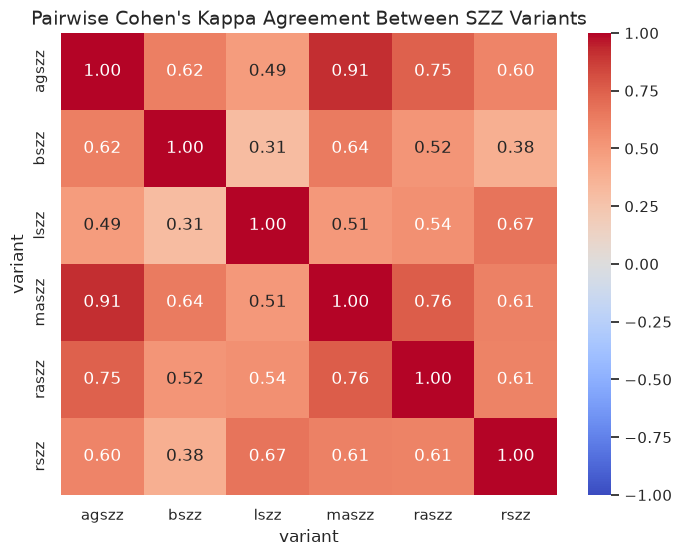

In [15]:
# Pivot the dataframe so each row is a commit and each column is an SZZ variant's prediction
pivot_df = merged_df.pivot_table(index=['project', 'commit_id'], columns='variant', values='predicted_label').dropna()

variants = pivot_df.columns
kappa_matrix = pd.DataFrame(index=variants, columns=variants, dtype=float)

for v1 in variants:
    for v2 in variants:
        if v1 == v2:
            kappa_matrix.loc[v1, v2] = 1.0
        else:
            kappa_matrix.loc[v1, v2] = cohen_kappa_score(pivot_df[v1], pivot_df[v2])

plt.figure(figsize=(8, 6))
sns.heatmap(kappa_matrix, annot=True, cmap='coolwarm', vmin=-1, vmax=1, fmt=".2f")
plt.title("Pairwise Cohen's Kappa Agreement Between SZZ Variants", fontsize=14)
plt.show()
